# Q1

In [21]:
import pandas as pd

In [22]:
ppl = pd.read_csv('unique_people_dataset_2000.csv')
teachers = pd.read_csv('all_teacher.csv')
ppl.head()

,name,age,height,weight,occupation,location
0,Jeffrey Mason,59,173.0,97.1,Teacher,city_north
1,Gina Deleon,69,149.8,97.2,Mechanic,city_west
2,Victoria Davis,54,171.2,60.0,Pilot,city_west
3,Angela Torres,46,162.7,72.7,Scientist,city_north
4,Tara Pace,58,197.4,51.1,Analyst,city_east


In [23]:
# age 30-45
# weight 50-100
# height 160-190
suspectPpl = ppl[(ppl['age'] >= 30) & (ppl['age'] <= 45) & (ppl['height'] >= 160) & (ppl['height'] <=190) & (ppl['weight'] >= 50) & (ppl['weight'] <= 100) & ((ppl['location'] == "city_south") | (ppl['location'] == 'city_east'))]
print (suspectPpl)

                   name  age  height  weight  occupation    location
8        Robert Collins   32   180.7    71.5      Writer   city_east
12      Patricia Walker   34   170.2    75.8   Architect  city_south
102         Kevin Green   30   162.9    75.6  Consultant   city_east
123   Brittany Gonzalez   44   183.1    68.9    Mechanic  city_south
124         Lisa Chavez   32   183.4    59.4     Analyst  city_south
...                 ...  ...     ...     ...         ...         ...
1952     Carol Williams   41   169.7    70.1       Nurse  city_south
1963          Kerry Day   45   169.3    83.0    Mechanic  city_south
1978      Jhon Williams   44   169.4    85.9     Teacher  city_south
1989         Lori Clark   44   180.2    51.9     Analyst  city_south
1999    Devon Blanchard   33   181.5    83.0   Scientist   city_east

[113 rows x 6 columns]


In [24]:
susTeachers = teachers[(teachers['age'] >= 30) & (teachers['age'] <= 45) & (teachers['height'] >= 160) & (teachers['height'] <= 190) & (teachers['weight'] >= 50) & (teachers['weight'] <= 100) & ((teachers['location'] == 'city_east') | (teachers['location'] == 'city_south'))]
print(susTeachers)

             name  age  height  weight occupation    location  Joining year
57    Laura Davis   32   164.5    95.7    Teacher   city_east          2024
82  Jhon Williams   44   169.4    85.9    Teacher  city_south          2010


In [25]:
# since 'He doesn't trust people easily eiter, his close friend would have been friend since long.', I assume the teacher must have been working for many years, say > 5
suspect = susTeachers[susTeachers['Joining year'] < 2026 - 5]
print(suspect)

             name  age  height  weight occupation    location  Joining year
82  Jhon Williams   44   169.4    85.9    Teacher  city_south          2010


So Mr. John Williams is most likely the killer.

# Q2

In [26]:
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("rocket_fuel_data.csv")

In [27]:
print(df.head())
print(df.shape)

      Fuel_Type  Temperature_C  Pressure_atm  Thrust_kN  Efficiency_Percent  \
0      HydroX-9         3200.0          85.4     1450.0                88.5   
1  NebulaFuel-3         2800.0           NaN     1200.0                76.2   
2  PlasmaCore-7         4100.0         120.3     2100.0                92.1   
3   CryoBlast-2         1900.0          60.1      850.0                65.4   
4      HydroX-9         3500.0          95.2     1680.0                90.3   

  Reactor_Stability  Oxygen_Level_Percent Target_Planet  
0            Stable                  21.3          Mars  
1          Unstable                  19.8         Venus  
2            Stable                  22.7       Jupiter  
3            Stable                  20.1          Moon  
4            Stable                   NaN          Mars  
(40, 8)


In [28]:
df["Temperature_C"] = df["Temperature_C"].fillna(df["Temperature_C"].mean())
df["Oxygen_Level_Percent"] = df["Oxygen_Level_Percent"].fillna(df["Oxygen_Level_Percent"].mean())
df["Efficiency_Percent"] = df["Efficiency_Percent"].fillna(df["Efficiency_Percent"].median())
df["Pressure_atm"] = df["Pressure_atm"].fillna(df["Pressure_atm"].median())
df["Thrust_kN"] = df["Thrust_kN"].fillna(df["Thrust_kN"].median())

In [29]:
df = df.sort_values("Efficiency_Percent", ascending=False)
df = df.sort_values("Temperature_C", ascending=True, kind="stable")
print(df.head())
df = df.reset_index(drop=True)
print(df.head())


      Fuel_Type  Temperature_C  Pressure_atm  Thrust_kN  Efficiency_Percent  \
12  CryoBlast-2         1800.0          58.6      790.0                62.1   
3   CryoBlast-2         1900.0          60.1      850.0                65.4   
37  CryoBlast-2         1950.0          61.0      810.0                63.3   
27  CryoBlast-2         2000.0          63.7      830.0                64.0   
7   CryoBlast-2         2100.0          65.3      920.0                68.2   

   Reactor_Stability  Oxygen_Level_Percent Target_Planet  
12          Unstable                  19.5          Moon  
3             Stable                  20.1          Moon  
37            Stable                  20.0          Moon  
27          Unstable                  19.7          Moon  
7             Stable                  20.5          Moon  
     Fuel_Type  Temperature_C  Pressure_atm  Thrust_kN  Efficiency_Percent  \
0  CryoBlast-2         1800.0          58.6      790.0                62.1   
1  CryoBlast-2 

In [30]:
df["Power_Index"] = df["Thrust_kN"]*df["Efficiency_Percent"]
print(df.head())

     Fuel_Type  Temperature_C  Pressure_atm  Thrust_kN  Efficiency_Percent  \
0  CryoBlast-2         1800.0          58.6      790.0                62.1   
1  CryoBlast-2         1900.0          60.1      850.0                65.4   
2  CryoBlast-2         1950.0          61.0      810.0                63.3   
3  CryoBlast-2         2000.0          63.7      830.0                64.0   
4  CryoBlast-2         2100.0          65.3      920.0                68.2   

  Reactor_Stability  Oxygen_Level_Percent Target_Planet  Power_Index  
0          Unstable                  19.5          Moon      49059.0  
1            Stable                  20.1          Moon      55590.0  
2            Stable                  20.0          Moon      51273.0  
3          Unstable                  19.7          Moon      53120.0  
4            Stable                  20.5          Moon      62744.0  


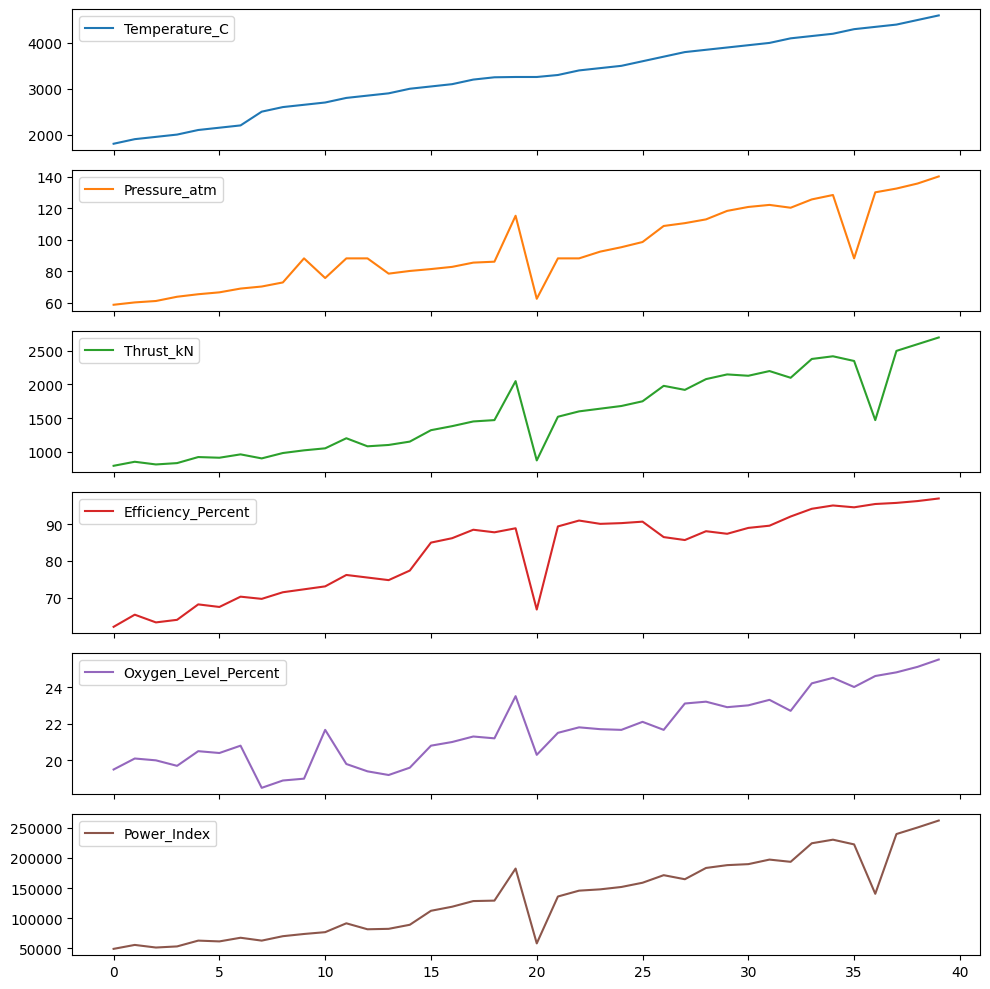

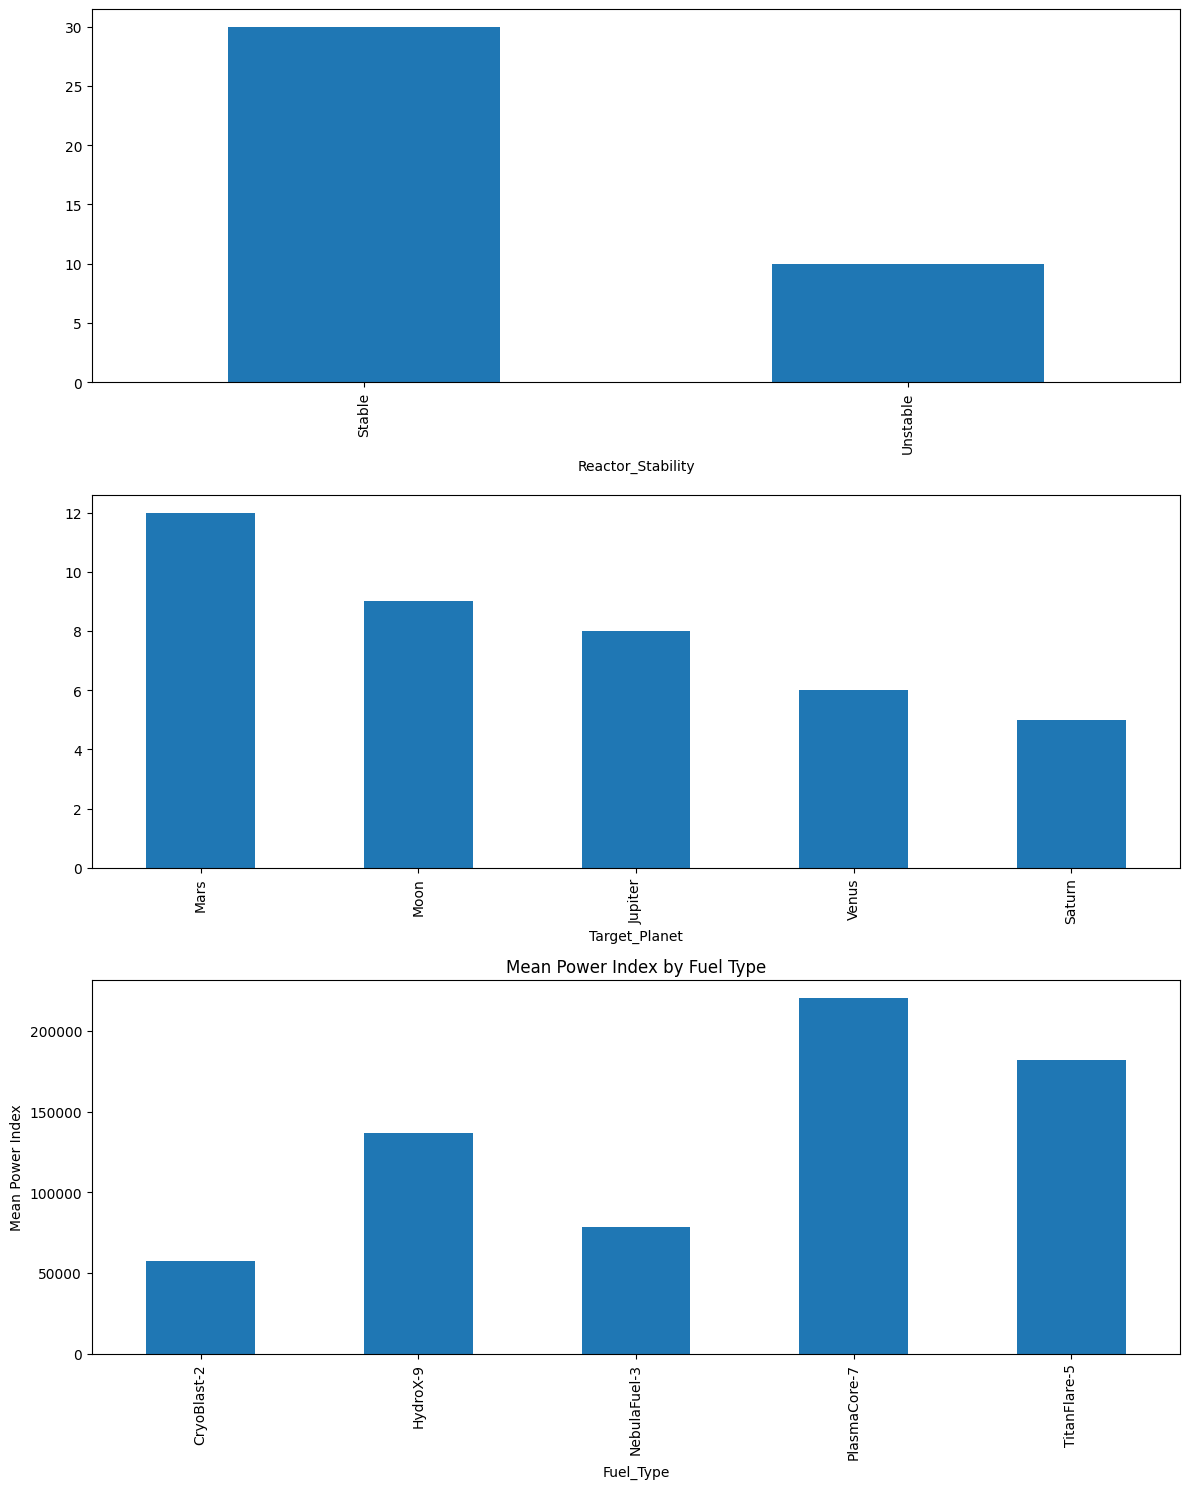

In [37]:
df.select_dtypes(include='number').plot(subplots=True,figsize=(10,10))
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(3, 1, figsize=(12, 15))
df["Reactor_Stability"].value_counts().plot(kind="bar", ax=ax[0])
df["Target_Planet"].value_counts().plot(kind="bar", ax=ax[1])
df.groupby("Fuel_Type")["Power_Index"].mean().plot(kind="bar", ax=ax[2])
ax[2].set_title("Mean Power Index by Fuel Type")
ax[2].set_ylabel("Mean Power Index")
plt.tight_layout()
plt.show()